In [2]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
from sklearn.linear_model import LinearRegression
import psana

In [1]:
###############################################
runNumbers = [400]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
folder = '/sdf/data/lcls/ds/cxi/cxil1006021/hdf5/smalldata/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = ['CXI-DG2-BMMON-WF/ROI_rebin_data',
                   #'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'ipm_dg2/sum',
                   'ipm_dg2/peaks',
                   'ipm_dg2/xpos',
                   'ipm_dg2/ypos',
                    #'ipm_dg3/sum',
                   #'ipm_hfx_dg2/sum',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  #'CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                  #'dg2_traces'
                   'ipm_dg2/sum'
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
# dg3 = data['ipm_dg3/sum']    # downstream diode x-ray intensity
# pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
#dg2Trace = data['CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data']
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['dg2_traces'][()][:,:,::8] # Dg2 traces, downsampled by a factor of 8
#dg2Sum = data['ipm_dg2/sum']
#dg2Sum = np.sum(np.sum(data['CXI-DG2-BMMON-WF/ROI_rebin_data'],axis=1),axis=1)
dg2traces = data['CXI-DG2-BMMON-WF/ROI_rebin_data'][()][:,:,::8] # Downsampling by a factor of 8, makes the refitting much better in the long run
ipm = data['ipm_dg2/sum']
ipmpeaks = data['ipm_dg2/peaks']
xpos = data['ipm_dg2/xpos']
ypos = data['ipm_dg2/ypos']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
# spec = spec[0:-2];
# azavFiltered = azavFiltered[1:-1];
# azav = azav[1:-1];
# xrayOn = xrayOn[1:-1];
# xrayOn2 = xrayOn2[1:-1];
# laserOn = laserOn[1:-1];
# dg2traces = dg2traces[1:-1];
# ipm = ipm[1:-1]
#dg2tracesFull = dg2tracesFull[1:-1];
#dg2Sum = dg2Sum[1:-1];

NameError: name 'combineRuns' is not defined

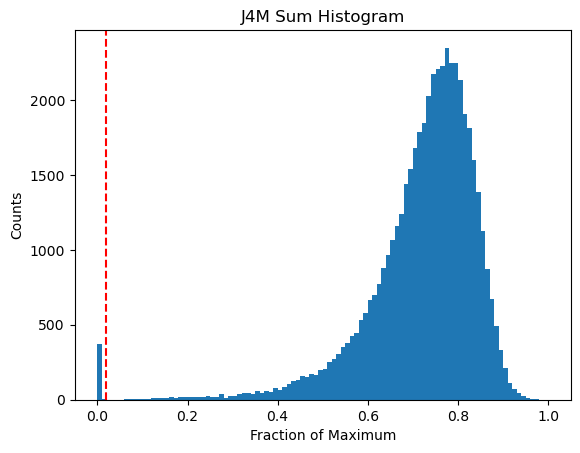

In [6]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.02
##########
scattered_xrays = np.sum(azav*qbinSize,axis=-1)
scattered_xraysFiltered = np.sum(azavFiltered*qbinSizeFiltered,axis=-1)

plt.hist(scattered_xrays/scattered_xrays.max(),bins=100)
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodSpecIdx = (xrayOn2) & (scattered_xrays/scattered_xrays.max()>scattering_cutoff)
specGood = spec[goodSpecIdx]
dg2Good = dg2traces[goodSpecIdx][0:5000]
J4MSum = scattered_xrays[goodSpecIdx][0:5000]
ipm5k = ipm[goodSpecIdx][0:5000]

### Processing the DG2 data

In [20]:
# First doing a background subtraction for each shot.
dg2PeakVals = np.zeros(dg2Good.shape[:2])
for i in range(dg2Good.shape[0] - 1): # Looping through each shot
    for j in range(dg2Good.shape[1]):
        trace = dg2Good[i,j]
        baseline = trace[0:10].mean()
        fixedTrace = (trace-baseline)*-1
        dg2PeakVals[i,j] = fixedTrace.max()

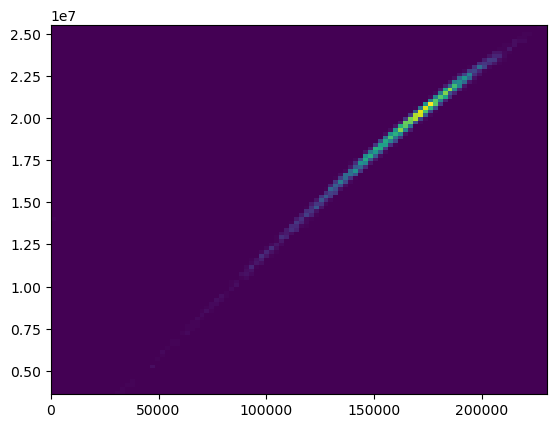

In [21]:
dg2Sum = dg2PeakVals.sum(axis=1)
plt.hist2d(dg2Sum,J4MSum,bins=100);

In [13]:
np.array(det.raw(evt)).shape

(16, 4096)

In [44]:
import psana
import numpy as np
##########################
runNumber=15
experiment='cxil1037623'
nTotEvents = 1000
##########################
dsname = 'exp=%s:run=%d:smd' % (experiment , runNumber) 
ds = psana.DataSource(dsname)
det = psana.Detector('CXI-DG2-BMMON-WF') # Wave8 Detector Traces
dg2Traces = np.zeros([nTotEvents, 8, 4096]) # Preallocation

nEvent = 0
for evt in ds.events():
    if nEvent == nTotEvents-1:
        break
    nEvent += 1
    dg2Traces[nEvent] = det.raw(evt)[8:16] # Pull the data out

In [45]:
Sum, xpos, ypos, peaks = recalculateDG2IPM(dg2Traces)

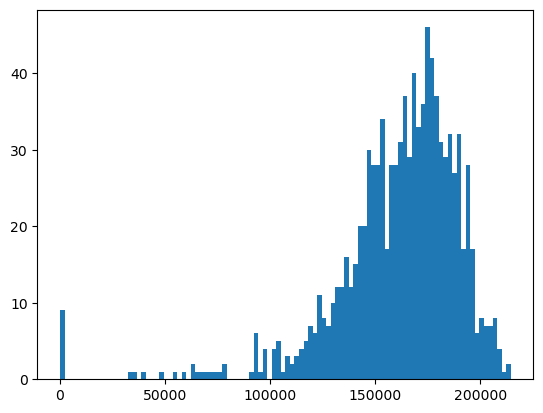

In [47]:
plt.hist(Sum,100);

In [7]:
import psana
##########################
runNumber=15
experiment='cxil1037623'
##########################
dsname = 'exp=%s:run=%d:smd' % (experiment , runNumber) 
#print(psana.DetNames('all'))
ds = psana.DataSource(dsname)

det = psana.Detector('CXI-DG2-BMMON')

nTotEvents = 10

x = np.zeros(nTotEvents)
y = np.zeros(nTotEvents)
intensity = np.zeros(nTotEvents)

nEvents = 0
for evt in ds.events():
    if nEvents == nTotEvents-1:
        break
    nEvents += 1
    x[nEvents] = det.get(evt).X_Position()
    y[nEvents] = det.get(evt).Y_Position()
    intensity[nEvents] = det.get(evt).TotalIntensity()
yfilt = y[goodSpecIdx[0:nTotEvents]][0:5000]
xfilt = x[goodSpecIdx[0:nTotEvents]][0:5000]

2025-03-07 05:41:55.699 [WRN] {XtcInput.XtcStreamDgIter} XtcStreamDgIter.cpp:299 - control stream has two datagrams with the same seconds/nanoseconds timestamp. The latter one is not marked as a split event. REMOVING the existing one, and Discarding the latter one: path=/sdf/data/lcls/ds/cxi/cxil1037623/xtc/smalldata/cxil1037623-r0015-s80-c00.smd.xtc offset=1537438 sec=1740486017 nano=408911494 fiducials=97926 transition=L1Accept
2025-03-07 05:41:55.787 [WRN] {XtcInput.XtcStreamDgIter} XtcStreamDgIter.cpp:299 - control stream has two datagrams with the same seconds/nanoseconds timestamp. The latter one is not marked as a split event. REMOVING the existing one, and Discarding the latter one: path=/sdf/data/lcls/ds/cxi/cxil1037623/xtc/smalldata/cxil1037623-r0015-s80-c00.smd.xtc offset=1555474 sec=1740486017 nano=692289260 fiducials=98028 transition=L1Accept


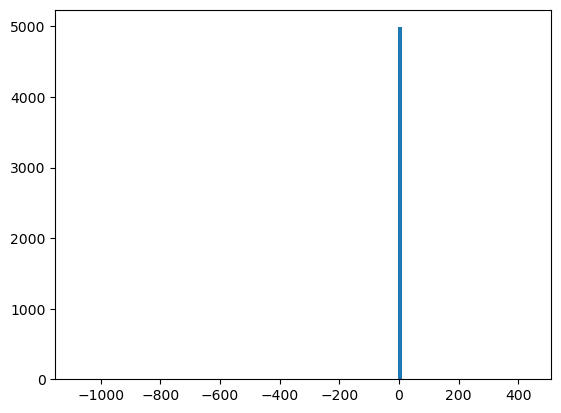

In [8]:
plt.hist(yfilt,bins=100);

Text(0.5, 1.0, 'IPM Beam center from CXI-DG2-BMMON')

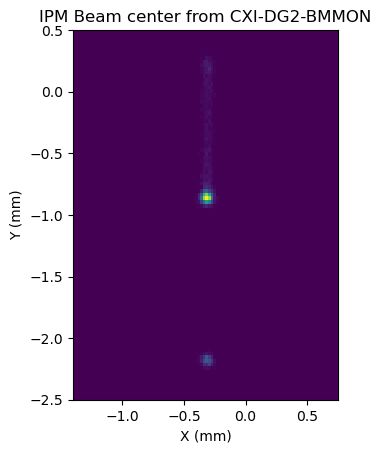

In [61]:
ymask = (yfilt<3) & (yfilt>-5)
xmask = (xfilt<0) & (xfilt>-1)
mask = ymask & xmask
plt.hist2d(xfilt[mask],yfilt[mask],bins=100,range=[[-1.4,0.75],[-2.5,0.5]])
#plt.ylim(-2.25,0.75)
plt.axis('image')
plt.ylabel('Y (mm)')
plt.xlabel('X (mm)')
plt.title('IPM Beam center from CXI-DG2-BMMON')
#plt.hist(yfilt[ymask],bins=20)

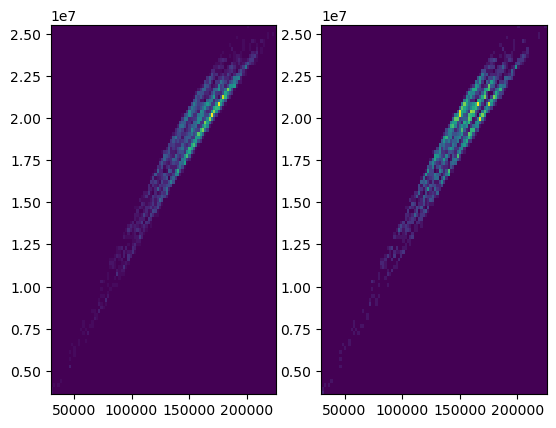

In [25]:

plt.subplot(1,2,1)
plt.hist2d(ipm5k,J4MSum,bins=100);
plt.subplot(1,2,2)
plt.hist2d(ipm5k[mask],J4MSum[mask],bins=100);

In [94]:
##########################
runNumber=166
experiment='cxil1037623'
##########################
dsname = 'exp=%s:run=%d:smd' % (experiment , runNumber) 
#print(psana.DetNames('all'))
ds = psana.DataSource(dsname)

det = psana.Detector('CXI:MKS670:READING')

nTotEvents = 10000

x = np.zeros(nTotEvents)
y = np.zeros(nTotEvents)
intensity = np.zeros(nTotEvents)

nEvents = 0
for evt in ds.events():
    if nEvents == nTotEvents-1:
        break
    nEvents += 1
    x[nEvents] = det.get(evt).X_Position()
    y[nEvents] = det.get(evt).Y_Position()
    intensity[nEvents] = det.get(evt).TotalIntensity()

KeyError: 'Unknown DetInfo device type: CXI:MKS670:READING (source: CXI:MKS670:READING)'